

<h1><b>GROUP: FEMBOY , BSIT 3C </b> <br></h1>
<b>MEMBERS:</b> <br>
Brucelo, Alyssa Mae B.<br>
Ebuenga, Kristel Ann B.<br>
Fenis, Austin B.<br>
Marfil, John Marvin G.<br>

<b>Project Title: Crime Incident Pattern Analysis</b> <br>
SDG: SDG 16 – Peace and Justice

Objectives:
*  Identifying high-crime areas using spatial clustering
*  Trend analysis of crime type frequency over time

**KAGGLE LINK OF DATASET USED:** <Br> https://www.kaggle.com/datasets/venkatsairo4899/los-angeles-crime-data-2020-2023?select=Crime_Data_from_2020_to_Present.csv

<h1><b>WEEK 3: CHOOSING THE ALGORITHM</b> </h1>





<h3> <b>1.0 Initializing </b> </h3>



In [ ]:
!pip install pyspark

from google.colab import drive
drive.mount('/content/drive')

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = (
    SparkSession.builder.appName('BSIT3C_FEMBOY_WEEK3')
    .getOrCreate())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<h3> <b>2.0 Data Preparation for K-Means </b> </h3>



In [ ]:
#2.O Data Preparation for K-Means

#2.1 Import necessary libraries
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.feature import StandardScaler

#2.2 Load the clean parquet file (refer to Week 2)
df = spark.read.parquet("/content/drive/MyDrive/BIGD/preprocessed1_femb.parquet")

#2.3 Assemble LAT and LON into a single feature vector using VectorAssembler
assembler = VectorAssembler(
    inputCols = ["LAT", "LON"],
    outputCol = "features"
)

df = assembler.transform(df)

#2.4 Scale the features using StandardScaler
scaler = StandardScaler(
    inputCol = "features",
    outputCol = "scaled_features",
    withStd = True,
    withMean = True
)

scaler_model = scaler.fit(df)
df = scaler_model.transform(df)

#2.5 Cache for repeated use in Section 3.0
df = df.cache()
df.count()

<h3> <b>3.0 K-Means Model </b> </h3>


In [ ]:
#3.0 K-Means (Model)

#3.1 Import necessary libraries
from pyspark.ml.clustering import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

#3.2 Train K-Means using the df prepared in 2.0
kmeans = KMeans(featuresCol="scaled_features", k=5, seed=67)
kmeans_model = kmeans.fit(df)

#3.3 Assign cluster labels to each row
predictions = kmeans_model.transform(df)

#3.4 Print Inertia to see how tight the clusters are (lower = better)
print(f"Inertia : {kmeans_model.summary.trainingCost:.2f}")
print("\n Cluster Centers:")
for i, center in enumerate(kmeans_model.clusterCenters()):
  print(f"Cluster {i}: {center}")

#3.5 Convert 10% sample to Pandas for plotting (downsize para di magcrash)
plot_df = (
    predictions
    .select("LAT","LON", "prediction")
    .sample(fraction=0.1, seed=67)
    .toPandas()
)

#3.6 Visualize the clusters on a scatter plot
plt.figure(figsize=(13, 12))
sns.scatterplot(
    data=plot_df,
    x="LON", y="LAT",
    hue="prediction",
    palette="deep",
    s=10, alpha=0.5,
    legend="full"
)

plt.title("Crime Incident Clusters (K-Means)",
          fontsize=15, fontweight="bold", pad=12)
plt.xlabel("Longitude", fontsize=12)
plt.ylabel("Latitude", fontsize=12)
plt.legend(title="Cluster Zone", loc="upper right")
plt.tight_layout()
plt.show()



<h3> <b>4.0 Data Preparation for Linear Regression </b> </h3>


In [ ]:
#4.0 Data Preparation for Linear Regression

#4.1 Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import functions as F
from pyspark.sql import SparkSession

#4.2 Load the clean parquet file
df_lr = spark.read.parquet("/content/drive/MyDrive/BIGD/preprocessed1_femb.parquet")

# 4.2.1 Extract Year and Month if they don't exist
if "year" not in df_lr.columns or "month" not in df_lr.columns:
    df_lr = df_lr.withColumn("year", F.year("DATETIME_OCC")) \
                 .withColumn("month", F.month("DATETIME_OCC"))

#4.3 Aggregate crime counts by year and month
monthly_counts = (
    df_lr.groupBy("year", "month")
    .count()
    .orderBy("year", "month")
)

#4.4 Convert aggregated results to Pandas
pandas_counts = monthly_counts.toPandas()

#4.5 Build a proper date column from year and month columns
pandas_counts['Date'] = pd.to_datetime(pandas_counts[['year', 'month']].assign(DAY=1))
# Sort by date to ensure proper trend plotting
pandas_counts = pandas_counts.sort_values('Date')
pandas_counts = pandas_counts[pandas_counts['Date'] < '2024-01-01']

#4.6 Plot the raw monthly crime trend as a line chart
plt.figure(figsize=(12, 6))
sns.lineplot(data=pandas_counts, x='Date', y='count', marker='o', color='teal')
plt.title("Monthly Crime Trend (2020 - 2023)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Number of Incidents")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#4.7 Plot the average crime count per month as a bar chart
avg_monthly = pandas_counts.groupby('month')['count'].mean().reset_index()
plt.figure(figsize=(10, 5))
sns.barplot(data=avg_monthly, x='month', y='count', palette='viridis', hue='month', legend=False)
plt.title("Average Crime Incidents by Month Index", fontsize=14)
plt.xlabel("Month (1-12)")
plt.ylabel("Average Count")
plt.show()

#4.8 Save into as CSV to Google Drive
pandas_counts.to_csv("/content/drive/MyDrive/BIGD/monthly_crime_counts.csv", index=False)
print("Data saved successfully to /content/drive/MyDrive/BIGD/monthly_crime_counts.csv")

<h3> <b>5.0 Linear Regression (Model)</h3> </b>

In [ ]:
#5.0 Linear Regression (Model)

#5.1 Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

#5.2 Load CSV saved by Member 3 from Google Drive
df_regression = pd.read_csv("/content/drive/MyDrive/BIGD/monthly_crime_counts.csv")

#5.3 Convert dates into a numeric time index
df_regression['Date'] = pd.to_datetime(df_regression['Date'])
# Numeric time index (Jan 2020 = 0, Feb 2020 = 1, etc.)
df_regression['time_index'] = np.arange(len(df_regression))
# Reshape for Scikit-Learn to set up y = mX + b equation
X = df_regression[['time_index']].values
y = df_regression['count'].values

#5.4 Train the Linear Regression model on the monthly crime counts
model = LinearRegression()
model.fit(X, y)

#5.5 Generate predictions from the model
df_regression['trend_line'] = model.predict(X)
print(f"Regression Slope: {model.coef_[0]:.2f} crimes per month\n")

#5.6 Plot the trend line over the actual monthly counts
plt.figure(figsize=(14, 7))
# Actual historical data
plt.plot(df_regression['Date'],
          df_regression['count'],
          marker='o', color='teal',
          label='Actual Monthly Counts',
          alpha=0.6)
# Regression trend line
plt.plot(df_regression['Date'],
         df_regression['trend_line'],
         color='violet',
         linestyle='--',
         linewidth=2,
         label='Linear Trend (Prediction)')
plt.title("Linear Regression Model: Crime Trend Analysis", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Number of Incidents", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<h1> <b>WEEK 4: OPTIMIZING/FINETUNING MODELS </b> </h1>

<h3> <b>6.0 Elbow Method (Optimizing K-Means) </h3> </b>

+---------+--------------------+----+-----------+-----------+------+--------------------+--------+--------+------------+---------+--------------------+------+------------+--------------------+-------+---------+-------------------+-------------------+--------------------+
|    DR_NO|           Date_Rptd|AREA|  AREA_NAME|Rpt_Dist_No|Crm_Cd|         Crm_Cd_Desc|Vict_Age|Vict_Sex|Vict_Descent|Premis_Cd|         Premis_Desc|Status| Status_Desc|            LOCATION|    LAT|      LON|       DATETIME_OCC|           features|     scaled_features|
+---------+--------------------+----+-----------+-----------+------+--------------------+--------+--------+------------+---------+--------------------+------+------------+--------------------+-------+---------+-------------------+-------------------+--------------------+
| 10304468|01/08/2020 12:00:...|   3|  southwest|        377|   624|battery - simple ...|      36|       f|           b|      501|single family dwe...|    ao| adult other|1100 w  39th 

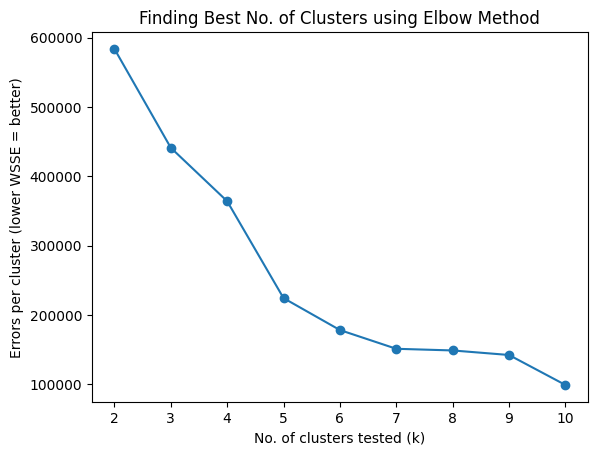


Baseline K          : 5
Optimal K           : 5
Baseline Inertia    : 224502.88
Optimized Inertia   : 99349.68


In [ ]:
#6.0 ELBOW METHOD

#6.1 Checking "df" from Task #3 before reuse in this task.

df.show(5)
df.printSchema()

#6.2 Create a list for storing error values for each "k" cluster.
elbow_clusterErrors = []

#6.3 Set number of clusters to try.
elbow_clusterRange = range(2, 11)

#6.4 Measure error for each "k" cluster.
print("---MEASURING ERRORS PER CLUSTER---")
for e in elbow_clusterRange:
  km = KMeans(featuresCol="scaled_features", k=e, seed=67)
  elbow_model = km.fit(df)
  wsse = elbow_model.summary.trainingCost
  elbow_clusterErrors.append(wsse)
  print(f"# of clusters: {e} -> Error: {wsse}")

#6.5 Visualizing the Elbow Graph from the measured errors
plt.plot(elbow_clusterRange, elbow_clusterErrors, marker='o')
plt.title("Finding Best No. of Clusters using Elbow Method")
plt.xlabel("No. of clusters tested (k)")
plt.ylabel("Errors per cluster (lower WSSE = better)")
plt.show()

#6.6
optimal_k = 5
print(f"\nBaseline K          : 5")
print(f"Optimal K           : {optimal_k}")
print(f"Baseline Inertia    : {kmeans_model.summary.trainingCost:.2f}")
print(f"Optimized Inertia   : {elbow_model.summary.trainingCost:.2f}")

<h3> <b>7.0 Retraining K-Means (Optimizing K-Means) + Week 3 Comparison </h3> </b>




In [162]:
#7.1 Retrain K-Means using K = 6, for comparison purposes
optimal_k = 5
kmeans_opt = KMeans(featuresCol="scaled_features", k=optimal_k, seed=67)
kmeans_model_opt = kmeans_opt.fit(df)

# Assign cluster labels
predictions_opt = kmeans_model_opt.transform(df)

#7.2 Convert 10% sample to Pandas for plotting (downsize para di magcrash)
plot_df_opt = (
    predictions_opt
    .select("LAT", "LON", "prediction")
    .sample(fraction=0.1, seed=67)
    .toPandas()
)


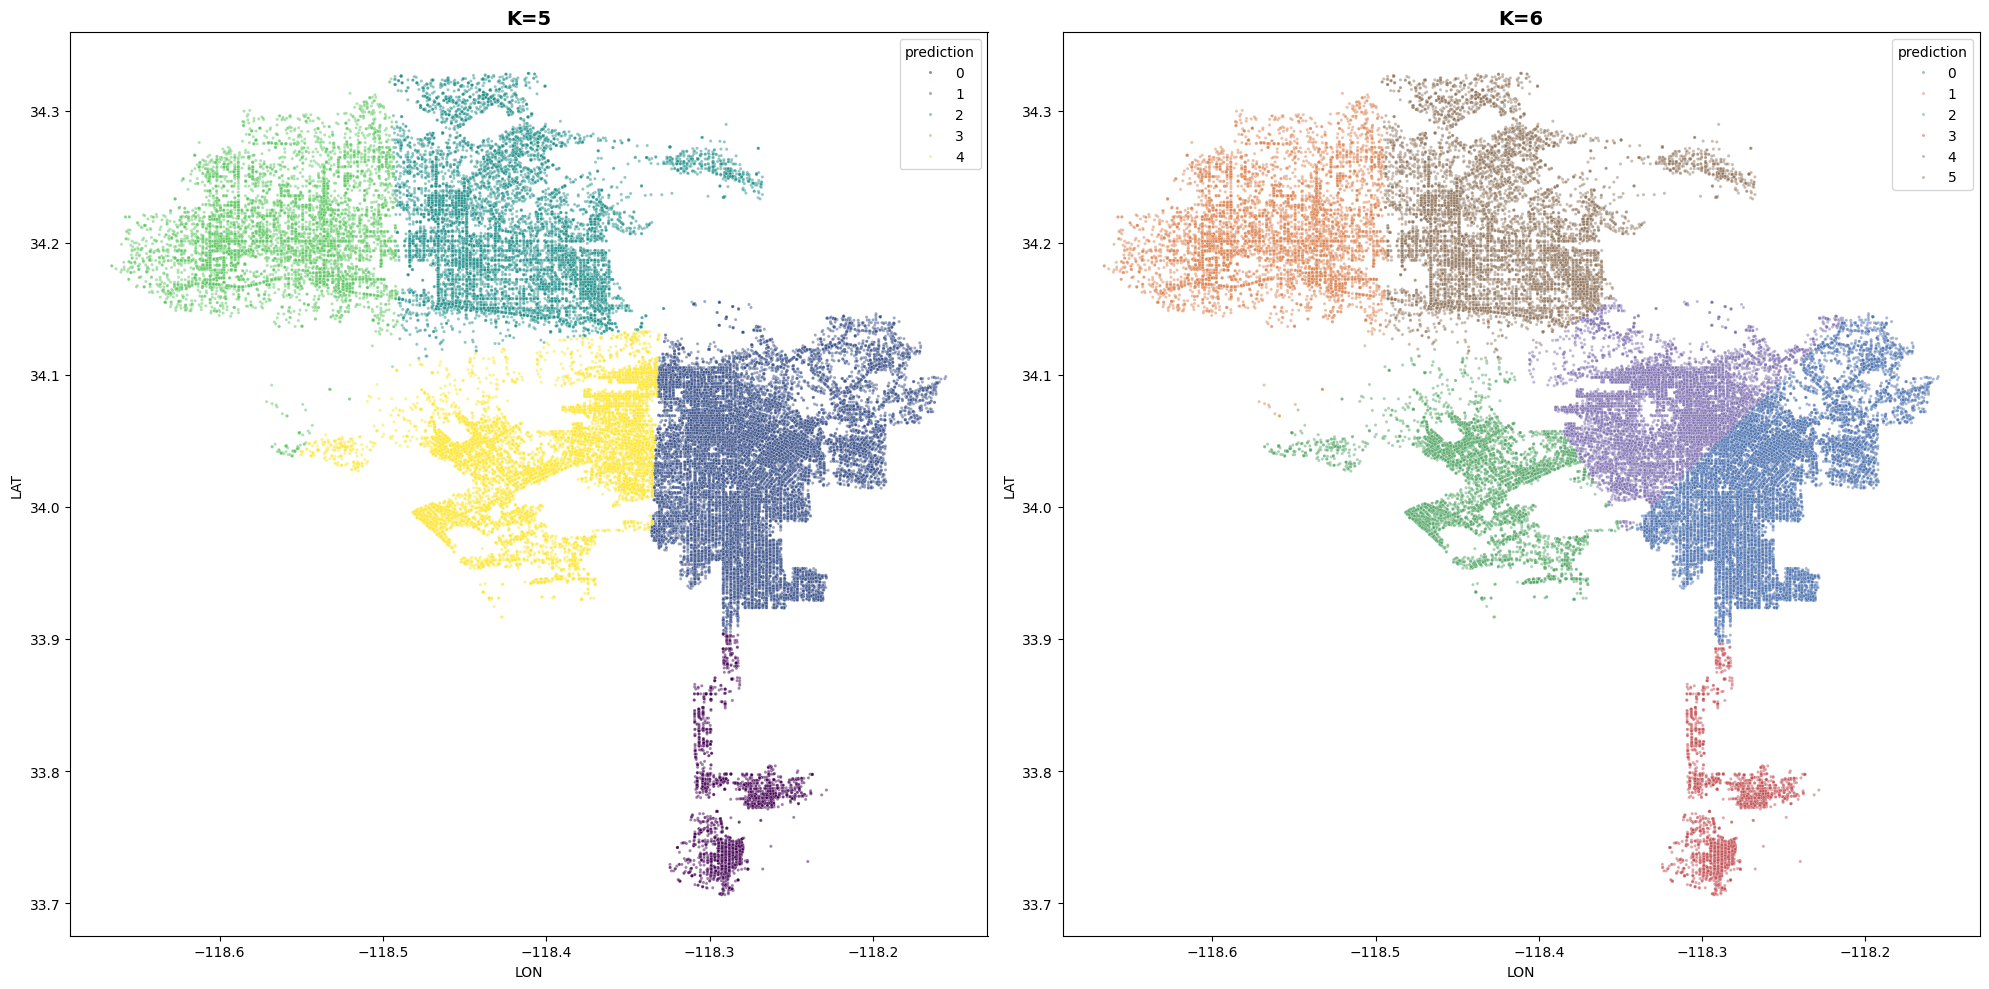

In [163]:
# 7.3 Side by side comparison OF K=5 AND K = 6 (Week 4)

# Train a K=6 model for comparison
kmeans_k6 = KMeans(featuresCol='scaled_features', k=6, seed=67)
kmeans_model_k6 = kmeans_k6.fit(df)
predictions_k6 = kmeans_model_k6.transform(df)

# Sample for plotting
plot_df_k5 = predictions_opt.select('LAT', 'LON', 'prediction').sample(fraction=0.1, seed=67).toPandas()
plot_df_k6 = predictions_k6.select('LAT', 'LON', 'prediction').sample(fraction=0.1, seed=67).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Plot K=5
sns.scatterplot(data=plot_df_k5, x='LON', y='LAT', hue='prediction', palette='viridis', s=5, alpha=0.5, ax=axes[0], legend='full')
axes[0].set_title('K=5', fontsize=14, fontweight='bold')

# Plot K=6
sns.scatterplot(data=plot_df_k6, x='LON', y='LAT', hue='prediction', palette='deep', s=5, alpha=0.5, ax=axes[1], legend='full')
axes[1].set_title('K=6', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

<h3> <b> 8.0 Finetuning Linear Regression into Polynomial Regression </h3> </b>


In [ ]:
#8.1 Import the necessary libraries
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge

#8.2 Load CSV saved in Section 4.0 and prepare features
df_regression = pd.read_csv("/content/drive/MyDrive/BIGD/monthly_crime_counts.csv")
df_regression['Date'] = pd.to_datetime(df_regression['Date'])

df_regression = df_regression[df_regression['Date'] < '2024-01-01']

df_regression['time_index'] = np.arange(len(df_regression))
y = df_regression['count'].values

#8.3 Add month as additional feature to capture seasonality
df_regression['month'] = df_regression['Date'].dt.month
X_features = df_regression[['time_index', 'month']].values

#8.4 Apply Polynomial transformation (degree=3) on the features
poly = PolynomialFeatures(degree=3)
X_poly_full = poly.fit_transform(X_features)

#8.5 Apply 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_poly_full, y, test_size=0.2, shuffle=True, random_state=42
)




<h3> <b>9.0 Retraining Linear Regression + Week 3 Comparison </h3> </b>


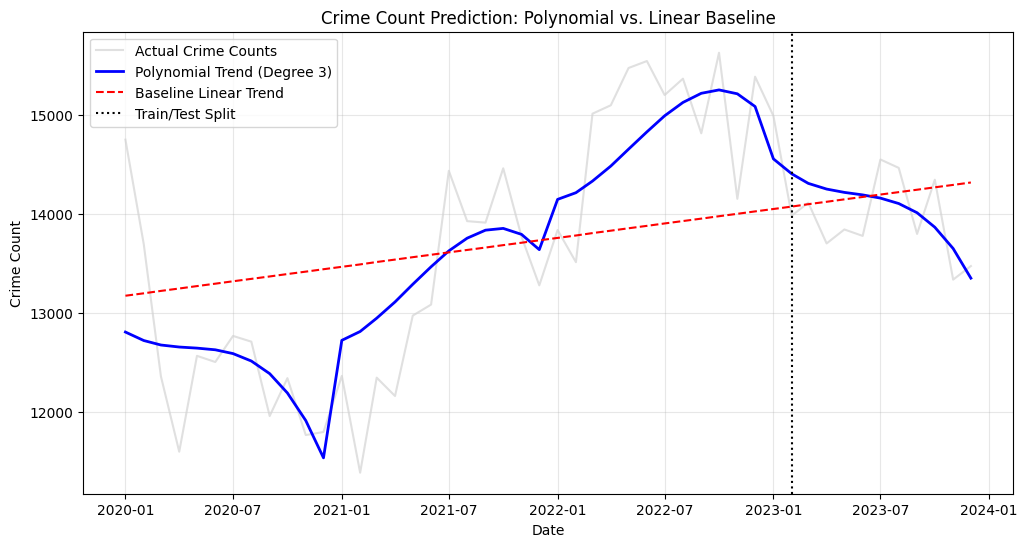

In [ ]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 9.1 Train the model on the training set only (Ridge for regularization)
poly_model = Ridge(alpha=100)
poly_model.fit(X_train, y_train)

# 9.2 Generate predictions on the full dataset
y_poly_pred = poly_model.predict(X_poly_full)

# 9.3 Regenerate baseline trend line (Linear Regression on time_index only)
baseline_model = LinearRegression()
X_baseline = df_regression[['time_index']].values
baseline_model.fit(X_baseline[:len(y_train)], y_train)
y_baseline_pred = baseline_model.predict(X_baseline)

# 9.4 & 9.5 Plotting the results
plt.figure(figsize=(12, 6))

plt.plot(df_regression['Date'], y, label='Actual Crime Counts', color='lightgray', alpha=0.7)
plt.plot(df_regression['Date'], y_poly_pred, label='Polynomial Trend (Degree 3)', color='blue', linewidth=2)
plt.plot(df_regression['Date'], y_baseline_pred, label='Baseline Linear Trend', color='red', linestyle='--')

split_date = df_regression['Date'].iloc[len(y_train)-1]
plt.axvline(x=split_date, color='black', linestyle=':', label='Train/Test Split')

plt.title('Crime Count Prediction: Polynomial vs. Linear Baseline')
plt.xlabel('Date')
plt.ylabel('Crime Count')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()